which player has won the most tournament in a single month?

step1: import libraries

In [23]:
import polars as pl
from  pathlib import Path

step2:define database path

In [5]:
CURRENT_DIR=Path.cwd()

PROJECT_PATH=CURRENT_DIR.parent
DATA_PATH=PROJECT_PATH / "tennis_data"/"Data"

print("project_path:",PROJECT_PATH)
print("data_path:",DATA_PATH)
print(DATA_PATH.exists())

project_path: /Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis
data_path: /Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data
True


step3:data discovery

In [7]:
data_path = PROJECT_PATH / "tennis_data" / "Data"

parquet_files=list(data_path.rglob("*.parquet"))

for file in parquet_files:
    print(file)
    

/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/venue_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/o

step4: load required database

In [10]:

event = pl.read_parquet(
    DATA_PATH / "event.parquet"
)

home = pl.read_parquet(
    DATA_PATH /"away_and_home_team"/"home_team.parquet"
)

away = pl.read_parquet(
    DATA_PATH /"away_and_home_team"/"away_team.parquet"
)

tournament = pl.read_parquet(
    DATA_PATH / "tournament_clean.parquet"
)

step5:check columns

In [11]:
print(event.columns)
print(home.columns)
print(away.columns)
print(tournament.columns)

['match_id', 'first_to_serve', 'home_team_seed', 'away_team_seed', 'custom_id', 'winner_code', 'default_period_count', 'start_datetime', 'match_slug', 'final_result_only', 'snapshot_date', 'match_datetime']
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']
['match_id', 'name', 'slug', 'gender', 'user_count', 'residence', 'birthplace', 'height', 'weight', 'plays', 'turned_pro', 'current_prize', 'total_prize', 'player_id', 'current_rank', 'name_code', 'country', 'full_name', 'snapshot_date']
['match_id', 'tournament_id', 'tournament_name', 'tournament_slug', 'tournament_unique_id', 'tournament_category_name', 'tournament_category_slug', 'user_count', 'ground_type', 'tennis_points', 'has_event_player_statistics', 'crowd_sourcing_enabled', 'has_performance_graph_feature', 'display_inverse_home_away_teams'

step6:make player's table

In [12]:
home_players = home.select(
    [
        "match_id",
        "player_id",
        "full_name"
    ]
).with_columns(
    pl.lit("home").alias("side")
)


away_players = away.select(
    [
        "match_id",
        "player_id",
        "full_name"
    ]
).with_columns(
    pl.lit("away").alias("side")
)


players = pl.concat(
    [
        home_players,
        away_players
    ]
)

players.head()

match_id,player_id,full_name,side
i64,i64,str,str
11998445,287803,"""Cazaux, Arthur""","""home"""
11998445,287803,"""Cazaux, Arthur""","""home"""
11998446,62790,"""Lestienne, Constant""","""home"""
11998446,62790,"""Lestienne, Constant""","""home"""
11998447,64580,"""Ćorić, Borna""","""home"""


step7:merge event with player

In [13]:
matches = event.join(
    players,
    on="match_id",
    how="left"
)

matches.head()

match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,snapshot_date,match_datetime,player_id,full_name,side
i64,i64,str,str,str,i64,i64,i64,str,bool,date,datetime[μs],i64,str,str
12011306,2,"""8""",null,"""RygsiDdc""",null,3,1706702700,"""passaro-marchenko""",false,2024-02-01,2024-01-31 12:05:00,258908,"""Passaro, Francesco""","""home"""
12011306,2,"""8""",null,"""RygsiDdc""",null,3,1706702700,"""passaro-marchenko""",false,2024-02-01,2024-01-31 12:05:00,16192,"""Marchenko, Illya""","""away"""
12017464,1,"""Q""",null,"""iBJcsdQYc""",2,3,1706702700,"""kuhl-salkova""",false,2024-02-01,2024-01-31 12:05:00,372053,"""Kuhl, Carolina""","""home"""
12017464,1,"""Q""",null,"""iBJcsdQYc""",2,3,1706702700,"""kuhl-salkova""",false,2024-02-01,2024-01-31 12:05:00,336308,"""Salkova, Dominika""","""away"""
12018812,null,"""Q""","""2""","""KMzbsLzjd""",2,3,1706702700,"""gokpinar-hardt""",false,2024-02-01,2024-01-31 12:05:00,186885,"""Hardt, Nick""","""away"""


step 8:check winner_code

In [14]:
matches.select(
    [
        "winner_code",
        "side",
        "full_name"
    ]
).head(20)

winner_code,side,full_name
i64,str,str
null,"""home""","""Passaro, Francesco"""
null,"""away""","""Marchenko, Illya"""
2,"""home""","""Kuhl, Carolina"""
2,"""away""","""Salkova, Dominika"""
2,"""away""","""Hardt, Nick"""
…,…,…
1,"""home""","""Yastremska, Dayana"""
1,"""away""","""Andreeva, Erika"""
2,"""home""","""Lopez, Noah"""


step9:select winner

In [15]:
winners = matches.filter(
    (
        (pl.col("winner_code") == 1) &
        (pl.col("side") == "home")
    )
    |
    (
        (pl.col("winner_code") == 2) &
        (pl.col("side") == "away")
    )
)

winners.head()

match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,snapshot_date,match_datetime,player_id,full_name,side
i64,i64,str,str,str,i64,i64,i64,str,bool,date,datetime[μs],i64,str,str
12017464,1,"""Q""",null,"""iBJcsdQYc""",2,3,1706702700,"""kuhl-salkova""",false,2024-02-01,2024-01-31 12:05:00,336308,"""Salkova, Dominika""","""away"""
12018812,null,"""Q""","""2""","""KMzbsLzjd""",2,3,1706702700,"""gokpinar-hardt""",false,2024-02-01,2024-01-31 12:05:00,186885,"""Hardt, Nick""","""away"""
12021601,1,"""LL""",null,"""RygsfTx""",1,3,1706702700,"""jorda-sanchis-marchenko""",false,2024-02-01,2024-01-31 12:05:00,57155,"""Jorda Sanchis, David""","""home"""
12017522,2,"""WC""",null,"""ArQsedIb""",1,3,1706703300,"""tubello-serban""",false,2024-02-01,2024-01-31 12:15:00,207654,"""Tubello, Alice""","""home"""
12019673,1,"""Q""",null,"""OjbdsJMFd""",2,3,1706703900,"""roura-llaverias-balus""",false,2024-02-01,2024-01-31 12:25:00,451884,"""Roura Llaverias, Ruth""","""away"""


In [16]:
winners.select(
    [
        "match_id",
        "full_name",
        "side",
        "winner_code"
    ]
).head(10)

match_id,full_name,side,winner_code
i64,str,str,i64
12017464,"""Salkova, Dominika""","""away""",2
12018812,"""Hardt, Nick""","""away""",2
12021601,"""Jorda Sanchis, David""","""home""",1
12017522,"""Tubello, Alice""","""home""",1
12019673,"""Roura Llaverias, Ruth""","""away""",2
12017465,"""Jorge, Francisca""","""home""",1
12019677,"""Munk Mortensen, Rebecca""","""home""",1
12016976,"""Yastremska, Dayana""","""home""",1
12017459,"""Pawelski, Martyn""","""away""",2


step10:extract match month

In [17]:
winners = winners.with_columns(
    pl.col("match_datetime")
    .dt.strftime("%Y-%m")
    .alias("month")
)

winners.select(
    [
        "full_name",
        "month"
    ]
).head()

full_name,month
str,str
"""Salkova, Dominika""","""2024-01"""
"""Hardt, Nick""","""2024-01"""
"""Jorda Sanchis, David""","""2024-01"""
"""Tubello, Alice""","""2024-01"""
"""Roura Llaverias, Ruth""","""2024-01"""


step11:count player wins per month

In [18]:
monthly_wins = (
    winners
    .group_by(
        [
            "full_name",
            "month"
        ]
    )
    .agg(
        pl.len().alias("wins")
    )
    .sort(
        "wins",
        descending=True
    )
)

monthly_wins.head(10)

full_name,month,wins
str,str,u32
"""Estable, Julieta""","""2024-03""",97
"""Faria, Jaime""","""2024-03""",83
"""Ribero, Franco""","""2024-03""",77
"""Chidekh, Clement""","""2024-02""",74
"""Ferrari, Francesco""","""2024-03""",73
"""Bosio, Victoria""","""2024-03""",71
"""Squire, Henri""","""2024-03""",71
"""Herrero Linana, Alicia""","""2024-03""",70
"""Falabella, Lautaro Agustin""","""2024-03""",70


check

In [19]:
monthly_wins.filter(
    pl.col("full_name") == "Estable, Julieta"
)

full_name,month,wins
str,str,u32
"""Estable, Julieta""","""2024-03""",97


In [20]:
winners.filter(
    pl.col("full_name") == "Estable, Julieta"
).height

97

step12:merge with tornament--->to identify the tournament where each match took place.(for more information)

In [21]:
winners_with_tournament = winners.join(
    tournament.select(
        [
            "match_id",
            "tournament_name"
        ]
    ),
    on="match_id",
    how="left"
)

winners_with_tournament.head()

match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,snapshot_date,match_datetime,player_id,full_name,side,month,tournament_name
i64,i64,str,str,str,i64,i64,i64,str,bool,date,datetime[μs],i64,str,str,str,str
12017464,1,"""Q""",null,"""iBJcsdQYc""",2,3,1706702700,"""kuhl-salkova""",false,2024-02-01,2024-01-31 12:05:00,336308,"""Salkova, Dominika""","""away""","""2024-01""","""Porto, Singles Main, W-ITF-POR…"
12018812,null,"""Q""","""2""","""KMzbsLzjd""",2,3,1706702700,"""gokpinar-hardt""",false,2024-02-01,2024-01-31 12:05:00,186885,"""Hardt, Nick""","""away""","""2024-01""","""Antalya, Singles Main, M-ITF-T…"
12021601,1,"""LL""",null,"""RygsfTx""",1,3,1706702700,"""jorda-sanchis-marchenko""",false,2024-02-01,2024-01-31 12:05:00,57155,"""Jorda Sanchis, David""","""home""","""2024-01""","""Koblenz, Germany"""
12017522,2,"""WC""",null,"""ArQsedIb""",1,3,1706703300,"""tubello-serban""",false,2024-02-01,2024-01-31 12:15:00,207654,"""Tubello, Alice""","""home""","""2024-01""","""Andrezieux-Boutheon, Singles M…"
12019673,1,"""Q""",null,"""OjbdsJMFd""",2,3,1706703900,"""roura-llaverias-balus""",false,2024-02-01,2024-01-31 12:25:00,451884,"""Roura Llaverias, Ruth""","""away""","""2024-01""","""Monastir, Singles Main, W-ITF-…"


In [22]:
winners_with_tournament.filter(
    pl.col("full_name") == "Estable, Julieta"
).select(
    [
        "full_name",
        "month",
        "tournament_name"
    ]
).head(20)

full_name,month,tournament_name
str,str,str
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
…,…,…
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"
"""Estable, Julieta""","""2024-03""","""Cordoba, Singles Main, W-ITF-A…"


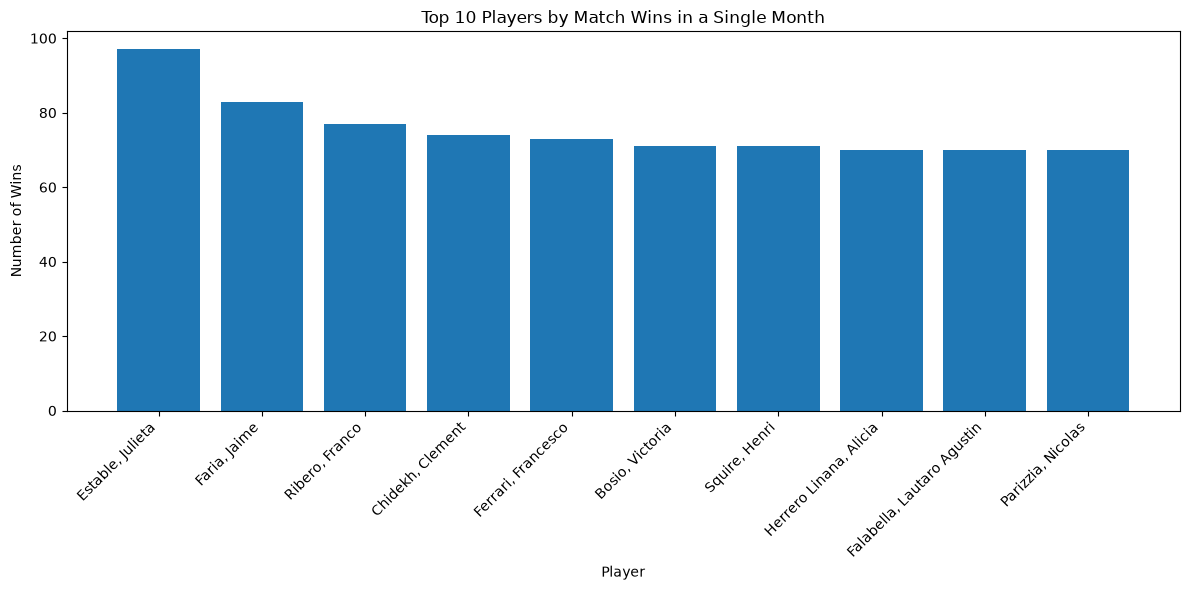

In [28]:
import matplotlib.pyplot as plt

top_players = monthly_wins.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_players["full_name"].to_list(),
    top_players["wins"].to_list()
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Player")
plt.ylabel("Number of Wins")
plt.title("Top 10 Players by Match Wins in a Single Month")

plt.tight_layout()

plt.show()